## **Text-to-image diffusion models**

2026-03-16 12:04:37.604776: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-16 12:04:37.604835: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-16 12:04:37.604867: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 12:04:37.614554: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 12:04:38.534772: W tensorflow/compiler/

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

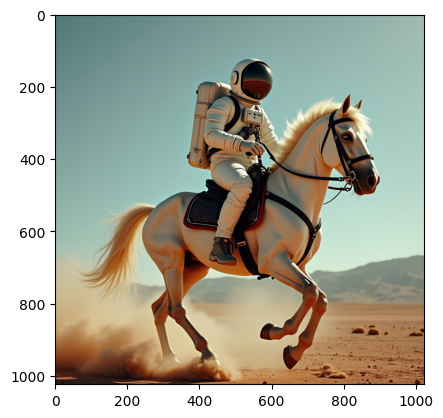

In [1]:
import torch
import matplotlib.pyplot as plt

from diffusers import DiffusionPipeline, StableDiffusion3Pipeline, FluxPipeline
from fan import FAN, personalized_t2i_encoder

prompt = ["A photograph of an astronaut riding a horse"]
ref = ["A retro-futuristic space exploration movie poster with bold, vibrant colors"]

# Load pipeline and FAN
pipeline = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-dev", torch_dtype = torch.bfloat16).to("cuda")
fan = personalized_t2i_encoder(pipeline, "./weight")

# Generate personalized images
generator = torch.Generator(pipeline.device).manual_seed(42)
with torch.no_grad():
    cond, pool_cond = fan(prompt, ref, weight = [1.0], alpha = 0.4, skip = -2, sample_size = 0)
    images = pipeline(
        prompt_embeds = cond.type(pipeline.dtype),
        pooled_prompt_embeds = pool_cond.type(pipeline.dtype) if pool_cond is not None else pool_cond,
        generator = generator
    ).images

plt.imshow(images[0])

## **unCLIP**

2026-03-16 11:37:50.295564: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-16 11:37:50.295630: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-16 11:37:50.295659: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 11:37:50.305876: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 11:37:51.427058: W tensorflow/compiler/

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

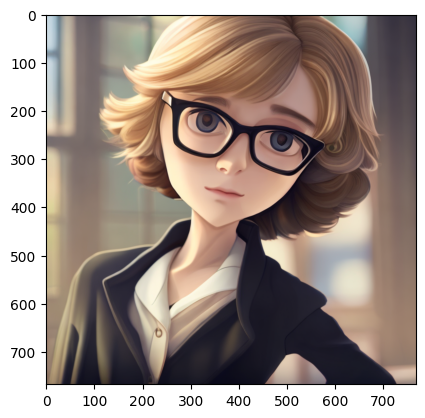

In [1]:
import torch
import matplotlib.pyplot as plt

from diffusers import StableUnCLIPImg2ImgPipeline
from diffusers.utils import load_image
from fan import FAN

face1 = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_girl1.png"
face2 = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_girl2.png"

size = (512, 512)
target = load_image(face1).resize(size)
ref = load_image(face2).resize(size)

# Load pipeline and FAN
pipeline = StableUnCLIPImg2ImgPipeline.from_pretrained("sd2-community/stable-diffusion-2-1-unclip", torch_dtype = torch.float16).to("cuda")
fan = FAN(pipeline.image_encoder, pipeline.feature_extractor)
#fan.model.vision_model.load_state_dict(torch.load("./openai_vit_l_14_224.pth")) #https://github.com/LiYinqi/un2CLIP

# Generate personalized images
generator = torch.Generator(pipeline.device).manual_seed(42)
with torch.no_grad():
    cond = fan.get_image_feature(target, ref, weight = [1.0], alpha = 0.5)
    images = pipeline(image_embeds = cond, generator = generator, num_inference_steps = 50).images
    
plt.imshow(images[0])

## **CLIP retrieval**

In [1]:
import numpy as np
import torch

from transformers import CLIPModel, CLIPProcessor
from diffusers.utils import load_image
from fan import FAN

def clip_score(feature, ref_feature, logit_scale = 100.0):
    ref_feature = np.expand_dims(ref_feature, axis = 0) if np.ndim(ref_feature) == 2 else ref_feature
    sim = logit_scale * np.einsum("bf,btf->bt",
                                  feature / np.linalg.norm(feature, axis = -1, keepdims = True),
                                  ref_feature / np.linalg.norm(ref_feature, axis = -1, keepdims = True))
    return sim

face1 = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_girl1.png"
face2 = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_girl2.png"
toy_story = "https://image.tmdb.org/t/p/original/1Lxqh5rFjMVMW4BUyGx4wIYQCYx.jpg"

size = (256, 256)
images = [load_image(url).resize(size) for url in [face1, face2, toy_story]]

model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
fan = FAN(model, processor, "./weight/L.pth")

with torch.no_grad():
    feature = fan.get_image_feature(images)
    #cond = fan.get_text_feature("A movie poster of 'toy story'") #[10.52388  17.932745 27.464468]
    cond = fan.get_text_feature("A movie poster of 'toy story'", ["A photo of face"], alpha = 0.8)
    score = clip_score(cond, feature)[0]
    print(score)

2026-03-16 12:14:59.024148: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-16 12:14:59.024222: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-16 12:14:59.024252: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 12:14:59.034655: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 12:15:00.219284: W tensorflow/compiler/

[19.114525 19.028845 17.244377]


## **Vision-language models**

In [1]:
import types
import torch

from transformers import AutoProcessor, LlavaForConditionalGeneration
from diffusers.utils import load_image
from fan import FAN

def personalized_vlm(model, x, alpha = 0.4, skip_pa = 0, **kwargs):
    old_func = model.get_image_features
    def test(self, pixel_values = None, vision_feature_layer = -2, **kwargs):
        ref = None
        if 1 < pixel_values.shape[0]:
            pixel_values, ref = pixel_values[:1], {"pixel_values":pixel_values[1:].unsqueeze(0)}
        return self.multi_modal_projector(fan({"pixel_values":pixel_values}, ref, alpha = alpha, skip_pa = skip_pa, pooling = False, normalize = False, skip = vision_feature_layer)[:, 1:])
    try:
        model.get_image_features = types.MethodType(test, model)
        res = model.generate(**x, **kwargs)
    except Exception as e:
        raise e
    finally:
        model.get_image_features = old_func
        del old_func
    return res

toy_story = "https://image.tmdb.org/t/p/original/1Lxqh5rFjMVMW4BUyGx4wIYQCYx.jpg"
john_wick = "https://image.tmdb.org/t/p/original/5k8sNEHoJ51ppGYbEcsdvhLnjx7.jpg"

size = (512, 512)
target = load_image(toy_story).resize(size)
ref = load_image(john_wick).resize(size)

model_id = "llava-hf/llava-1.5-7b-hf"
model = LlavaForConditionalGeneration.from_pretrained(model_id, torch_dtype = torch.float16).to("cuda")
processor = AutoProcessor.from_pretrained(model_id)
fan = FAN(model.vision_tower, processor)

query = "Describe this movie poster in detail."
conversation = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": query}]}]
prompt = processor.apply_chat_template(conversation, add_generation_prompt = True)
inputs = processor(images = [target] + [ref], text = prompt, return_tensors = "pt").to("cuda", model.dtype)

with torch.no_grad():
    output = personalized_vlm(model, inputs, alpha = 0.4, vision_feature_layer = -2, max_new_tokens = 200, do_sample = False)
    print(processor.decode(output[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True))

2026-03-15 14:09:37.998631: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 14:09:37.998696: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 14:09:37.998730: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 14:09:38.006352: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 14:09:39.197608: W tensorflow/compiler/

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some kwargs in processor config are unused and will not have any effect: num_additional_image_tokens. 
Expanding inputs for image tokens in LLaVa should be done in processing. Please add `patch_size` and `vision_feature_select_strategy` to the model's processing config or set directly with `processor.patch_size = {{patch_size}}` and processor.vision_feature_select_strategy = {{vision_feature_select_strategy}}`. Using processors without these attributes in the config is deprecated and will throw an error in v4.47.


The movie poster features a character from the animated movie "Toy Story." The character is prominently displayed in the center of the poster, with a blue background that complements the character's colors. The character appears to be a toy, possibly a Buzz Lightyear action figure, as it is holding a gun.

In the background, there are two smaller figures, one on the left side and the other on the right side of the poster. The overall design of the poster is visually appealing and captures the essence of the animated movie.
